In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

In [1]:
!pip install scipy -q

import requests, io
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import matplotlib.colors as mcolors
import scipy.io as iomat
import helpers
from TIMBRE import TIMBRE

# --- Load data ---
url = "https://api.figshare.com/v2/articles/24757638"
files = requests.get(url).json()['files']
f = next(x for x in files if x['name'] == 'data04.mat')
data = iomat.loadmat(io.BytesIO(requests.get(f['download_url']).content))

# --- Preprocess ---
LFPs = helpers.filter_data(data['lfps'], 2, fs=25, use_hilbert=True)
test_inds, train_inds = helpers.test_train(data['lapID'], which_phase=2, n_folds=5, which_fold=0)
wLFPs, _, _ = helpers.whiten(LFPs, train_inds)
print(f"LFPs shape: {LFPs.shape}, electrodes: {LFPs.shape[1]}")


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
LFPs shape: (91710, 192), electrodes: 192


In [2]:
m6, _, _ = TIMBRE(wLFPs, data['lapID'][:, 1], test_inds, train_inds, hidden_nodes=6)

In [3]:
def linearize_per_arm(lapID, which_phase):
    """
    Returns scalar linearized position in [0, 1] per timestep.
    Position 1 = port end of arm (lapID col3==2 samples).
    Excludes off-maze samples (arm==-1); those remain NaN.
    which_phase=2 (stay) gives degenerate position -- rat barely moves.
    """
    lin = np.full(len(lapID), np.nan)
    for arm in range(3):  # arms 0, 1, 2 -- not -1 (off-maze)
        mask = (lapID[:, 1] == arm) & (lapID[:, 3] == which_phase)
        if mask.sum() < 2:
            continue
        xy = np.stack([lapID[mask, 4], lapID[mask, 5]], axis=1)  # (N, 2) x,y coords
        xy_c = xy - xy.mean(axis=0)
        _, _, Vt = np.linalg.svd(xy_c, full_matrices=False)
        proj = xy_c @ Vt[0]  # project onto 1st PC (principal axis of motion)
        # orient so port-arrival samples (phase==2) cluster near position 1
        port_mask = lapID[mask, 3] == 2
        if port_mask.any() and proj[port_mask].mean() < proj.mean():
            proj = -proj
        pmin, pmax = proj.min(), proj.max()
        if pmax > pmin:
            proj = (proj - pmin) / (pmax - pmin)
        lin[mask] = proj
    return lin

In [4]:
def build_session_image(lapID, wLFPs_sess, model, which_phase=1, n_pos_bins=50):
    """
    Returns:
      image      : (n_trials, 3*n_pos_bins) float, NaN where no data
      vote_margin: same shape, fraction of timesteps voting for winning node
      trial_ids  : (n_trials,) int, sorted unique trial numbers
    """
    acts = helpers.layer_output(wLFPs_sess, model, 2)  # (T, n_nodes) post-softmax
    n_nodes = acts.shape[1]

    lin = linearize_per_arm(lapID, which_phase)
    pos_bins = np.floor(lin * n_pos_bins).astype(float)
    pos_bins[np.isnan(lin)] = np.nan
    pos_bins = np.clip(pos_bins, 0, n_pos_bins - 1)  # handle edge case lin==1.0

    # exclude arm==-1 (off-maze) from trial list
    trial_ids = np.unique(lapID[:, 0][lapID[:, 1] != -1]).astype(int)
    n_trials = len(trial_ids)
    image = np.full((n_trials, 3 * n_pos_bins), np.nan)
    vote_margin = np.full_like(image, np.nan)

    for ti, trial in enumerate(trial_ids):
        for arm in range(3):  # arm==-1 (off-maze) excluded -- only iterate 0,1,2
            mask = (
                (lapID[:, 0] == trial) &
                (lapID[:, 1] == arm) &
                (lapID[:, 3] == which_phase)
            )
            if mask.sum() == 0:
                continue
            arm_acts = acts[mask]      # (N_t, n_nodes)
            arm_bins = pos_bins[mask]  # (N_t,)
            col_offset = arm * n_pos_bins
            for b in range(n_pos_bins):
                bin_mask = arm_bins == b
                if bin_mask.sum() == 0:
                    continue
                votes = arm_acts[bin_mask].argmax(axis=1)  # winning node per timestep
                winner = np.bincount(votes, minlength=n_nodes).argmax()
                image[ti, col_offset + b] = winner
                vote_margin[ti, col_offset + b] = (votes == winner).mean()

    return image, vote_margin, trial_ids

In [5]:
def plot_trial_position_grid(sessions, which_phase=1, n_pos_bins=50):
    """
    sessions: list of dicts with keys 'lapID', 'wLFPs', 'model', 'label'
    Plots a 2x2 grid (up to 4 sessions). Y=trial, X=position, color=winning node.
    """
    node_colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00', '#a65628']
    cmap = mcolors.ListedColormap(node_colors[:6])
    cmap.set_bad(color='white')  # NaN bins appear white

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.ravel()
    im = None

    for i, sess in enumerate(sessions[:4]):
        ax = axes[i]
        image, _, trial_ids = build_session_image(
            sess['lapID'], sess['wLFPs'], sess['model'],
            which_phase=which_phase, n_pos_bins=n_pos_bins
        )
        img_masked = np.ma.masked_invalid(image)
        im = ax.imshow(
            img_masked, aspect='auto', origin='upper',
            cmap=cmap, vmin=-0.5, vmax=5.5,
            extent=[0, 3 * n_pos_bins, len(trial_ids), 0]
        )
        # arm boundary lines
        for boundary in [n_pos_bins, 2 * n_pos_bins]:
            ax.axvline(boundary, color='black', linewidth=1.5)
        ax.set_xlabel('Position bin')
        ax.set_ylabel('Trial number')
        ax.set_title(sess.get('label', f'Session {i+1}'))
        ax.set_xticks([n_pos_bins // 2,
                       n_pos_bins + n_pos_bins // 2,
                       2 * n_pos_bins + n_pos_bins // 2])
        ax.set_xticklabels(['Arm 1', 'Arm 2', 'Arm 3'])

    if im is not None:
        cbar = fig.colorbar(im, ax=axes, orientation='vertical', fraction=0.02, pad=0.04)
        cbar.set_ticks(range(6))
        cbar.set_ticklabels([f'Node {j}' for j in range(6)])
        cbar.set_label('Winning node')

    for j in range(len(sessions), 4):
        axes[j].set_visible(False)

    plt.suptitle(f'Trial x Position (phase={which_phase})', y=1.02)
    plt.tight_layout()
    return fig

2866/2866 ━━━━━━━━━━━━━━━━━━━━ 1s 256us/step


/var/folders/6_/nbb0t2054p73mx78hmf7r9mc0000gn/T/ipykernel_76340/1819654036.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


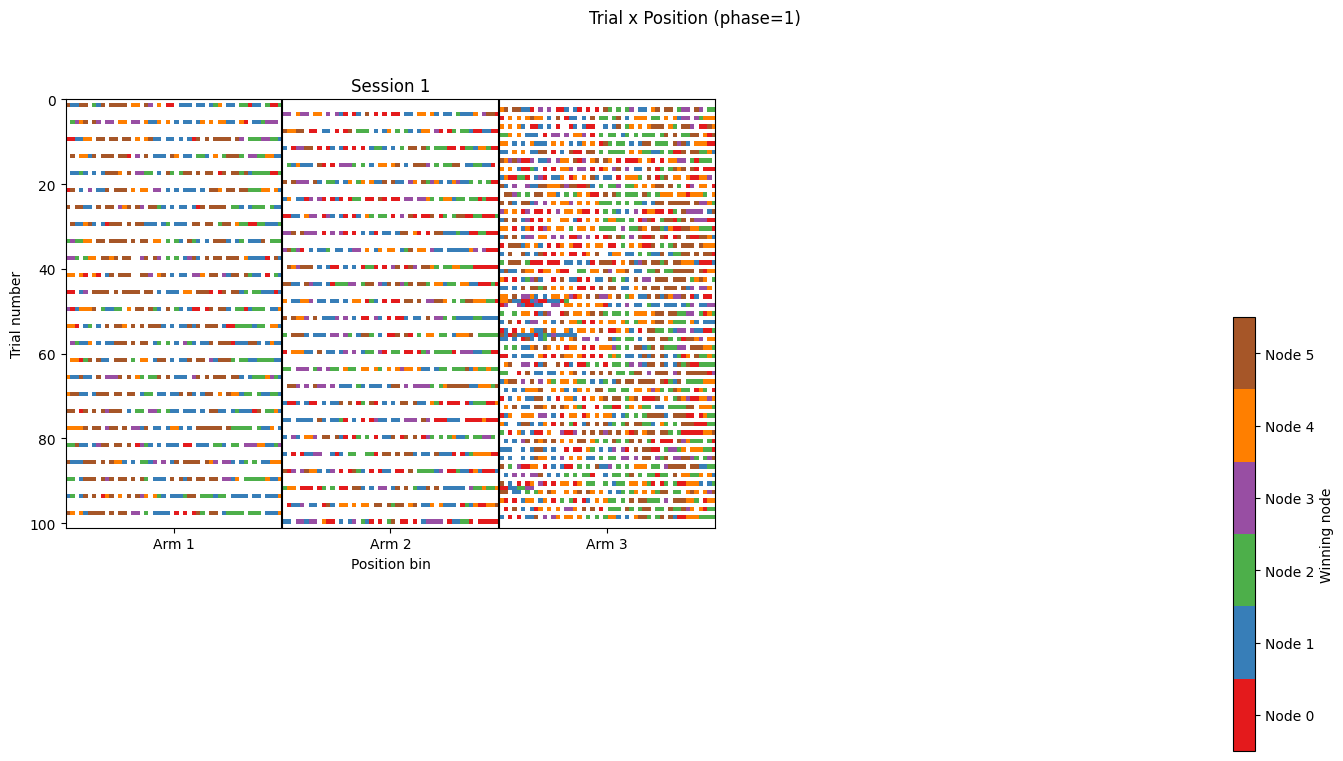

In [6]:
sessions = [
    {'lapID': data['lapID'], 'wLFPs': wLFPs, 'model': m6, 'label': 'Session 1'},
    # add up to 3 more dicts here for additional sessions
]
plot_trial_position_grid(sessions, which_phase=1, n_pos_bins=50)
plt.show()

In [7]:
# Sanity checks
lin = linearize_per_arm(data['lapID'], which_phase=1)
print(f"lin range: [{np.nanmin(lin):.3f}, {np.nanmax(lin):.3f}]  (should be [0, 1])")

image, vote_margin, trial_ids = build_session_image(
    data['lapID'], wLFPs, m6, which_phase=1, n_pos_bins=50
)
print(f"image shape: {image.shape}")
print(f"unique node values: {np.unique(image[~np.isnan(image)]).astype(int)}  (should be subset of 0-5)")
print(f"NaN fraction: {np.isnan(image).mean():.2%}")

lin range: [0.000, 1.000]  (should be [0, 1])
2866/2866 ━━━━━━━━━━━━━━━━━━━━ 1s 217us/step
image shape: (101, 150)
unique node values: [0 1 2 3 4 5]  (should be subset of 0-5)
NaN fraction: 75.91%
